# How well does the tuned model detect each fault, and how fast?

Four models (logistic regression, LightGBM, XGBoost, random forest) were
tuned per outer leave-one-load-out fold (nested Optuna, `keyframe.tuning`)
and refit on `raw+physics+rolling` (`docs/adr/0006-feature-set-for-modelling.md`),
with alarm parameters chosen inside the inner folds
(`keyframe.alarm.choose_alarm_params`, R10). This notebook reads the cached
`reports/results/04_models.csv` and `04_alarms.csv` outputs, never refits.

**Main findings:** XGBoost wins on pooled macro F1 (0.717), ahead of
LightGBM (0.667), random forest (0.648) and logreg (0.542), but every model
falls well short of the target (0.80) and its false alarm rate (12.2%) is
more than double the 5% target. Detection delay is honest, not
reassuring: XGBoost only ever raises a sustained alarm on 6 of the 13 fault
runs (median delay among those, 563 s / 9.4 min), so more than half the runs are
never detected at all. Scores computed without each run's first 10 minutes
after switch-on are close to the full scores, so gradual onset is not
hiding a much better underlying model.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from keyframe import audit, evaluate, experiments, paths

paths.FIGURES.mkdir(parents=True, exist_ok=True)
paths.RESULTS.mkdir(parents=True, exist_ok=True)

MODELS = ["logreg", "lightgbm", "xgboost", "random_forest"]

/home/user/KeyFrame/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Row-level comparison: which model generalises best to an unseen load?

Pooled macro F1 is the headline target (R15); per-fold mean/std shows the
spread across held-out loads.

In [2]:
models_results = pd.read_csv(paths.RESULTS / "04_models.csv")
pooled = models_results[models_results["fold"] == "pooled"].sort_values("macro_f1", ascending=False)
pooled[["model", "macro_f1", "accuracy", "false_alarm_rate", "worst_recall", "worst_recall_class"]]

,model,macro_f1,accuracy,false_alarm_rate,worst_recall,worst_recall_class
5,xgboost,0.717487,0.761268,0.122309,0.194494,TD
0,lightgbm,0.666881,0.738810,0.094155,0.112796,TD
10,random_forest,0.647841,0.578575,0.558360,0.317500,AF
15,logreg,0.541989,0.642051,0.246546,0.000892,TD


In [3]:
per_fold = models_results[models_results["fold"] != "pooled"].copy()
per_fold_stats = (
    per_fold.groupby("model")["macro_f1"].agg(["mean", "std"]).sort_values("mean", ascending=False)
)
per_fold_stats

,mean,std
model,,
xgboost,0.679138,0.136443
lightgbm,0.615860,0.264478
random_forest,0.590087,0.215958
logreg,0.587247,0.079715


In [4]:
best_model = str(pooled.iloc[0]["model"])
best_model

'xgboost'

## Per-fold spread: does the ranking hold at every load?

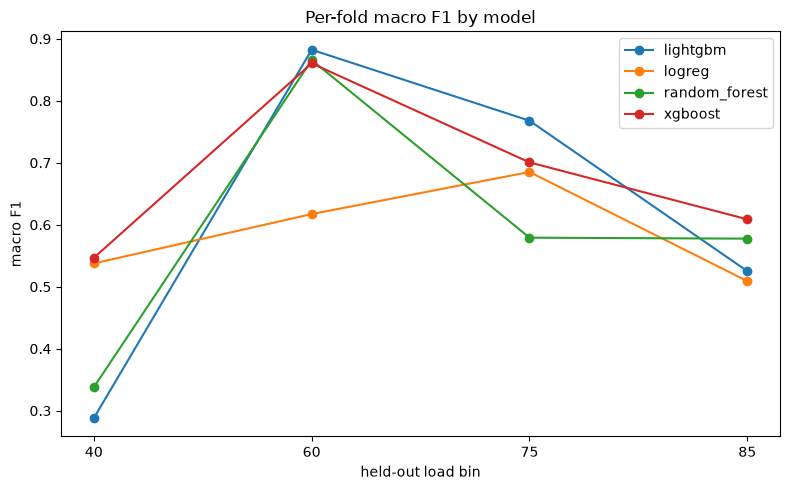

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
for model, group in per_fold.groupby("model"):
    group = group.sort_values("fold")
    ax.plot(group["fold"].astype(str), group["macro_f1"], marker="o", label=model)
ax.set_xlabel("held-out load bin")
ax.set_ylabel("macro F1")
ax.set_title("Per-fold macro F1 by model")
ax.legend()
fig.tight_layout()
fig.savefig(paths.FIGURES / "04_fold_scores.png", dpi=150)
plt.show()

## Tuned parameters per fold

From `models/tuning/<model>_fold<bin>.json` (R4); each fold is tuned only
on that fold's outer training rows.

In [6]:
tuned_rows = []
for model in MODELS:
    for fold in [40, 60, 75, 85]:
        params = experiments.load_tuned_params(model, fold)
        tuned_rows.append({"model": model, "fold": fold, **params})
tuned_params = pd.DataFrame(tuned_rows)
tuned_params

,model,fold,C,num_leaves,learning_rate,n_estimators,min_child_samples,feature_fraction,reg_lambda,max_depth,subsample,colsample_bytree,min_samples_leaf,max_features,max_samples
0,logreg,40,3.470267,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,logreg,60,4.570563,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,logreg,75,21.423022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,logreg,85,56.698495,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,lightgbm,40,NaN,20.0,0.002870,99.0,79.0,0.969749,3.795853,NaN,NaN,NaN,NaN,NaN,NaN
5,lightgbm,60,NaN,8.0,0.139837,80.0,72.0,0.510292,7.579480,NaN,NaN,NaN,NaN,NaN,NaN
6,lightgbm,75,NaN,7.0,0.178853,63.0,68.0,0.655856,0.120302,NaN,NaN,NaN,NaN,NaN,NaN
7,lightgbm,85,NaN,10.0,0.003061,61.0,12.0,0.529023,0.097414,NaN,NaN,NaN,NaN,NaN,NaN
8,xgboost,40,NaN,NaN,0.178853,63.0,NaN,NaN,0.120302,2.0,0.831261,0.655856,NaN,NaN,NaN
9,xgboost,60,NaN,NaN,0.178853,63.0,NaN,NaN,0.120302,2.0,0.831261,0.655856,NaN,NaN,NaN


## Pooled confusion matrix for the best model

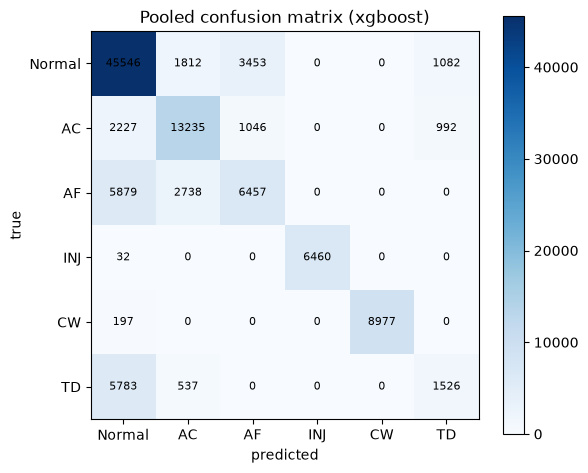

In [7]:
best_predictions = experiments.load_modelling(best_model)
confusion = evaluate.confusion(best_predictions["y_true"], best_predictions["y_pred"])

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(confusion.to_numpy(), cmap="Blues")
ax.set_xticks(range(len(confusion.columns)), confusion.columns)
ax.set_yticks(range(len(confusion.index)), confusion.index)
for i in range(len(confusion.index)):
    for j in range(len(confusion.columns)):
        ax.text(j, i, confusion.iat[i, j], ha="center", va="center", fontsize=8)
ax.set_xlabel("predicted")
ax.set_ylabel("true")
ax.set_title(f"Pooled confusion matrix ({best_model})")
fig.colorbar(im, ax=ax)
fig.tight_layout()
fig.savefig(paths.FIGURES / "04_confusion_best.png", dpi=150)
plt.show()

## Alarm-level results: detection delay per run

Alarm parameters (`min_duration_s`, `min_probability`) are chosen inside
each outer fold's inner folds (R10), then scored on the outer held-out
run. A blank delay means the model never raised a sustained alarm for
that run.

In [8]:
alarms_results = pd.read_csv(paths.RESULTS / "04_alarms.csv")
alarms_results[["run", "model", "fold", "delay_s", "class", "false_alarm_rate"]]

,run,model,fold,delay_s,class,false_alarm_rate
0,AC_Fouling_40_Load,lightgbm,40,NaN,NaN,0.000000
1,AF_Clogging_40_Load,lightgbm,40,NaN,NaN,0.000000
2,Turbine_Degradation_40_Load,lightgbm,40,NaN,NaN,0.000000
3,AC_Fouling_60_Load,lightgbm,60,725.0,AC,0.000000
4,AF_Clogging_60_Load,lightgbm,60,888.0,AF,0.000000
5,CW_Pump_Cavitation_60_Load,lightgbm,60,NaN,NaN,0.000000
6,Turbine_Degradation_60_Load,lightgbm,60,NaN,NaN,0.000000
7,AC_Fouling_75_Load,lightgbm,75,360.0,AC,0.124544
8,AF_Clogging_75_Load,lightgbm,75,NaN,NaN,0.124544
9,AC_Fouling_85_Load,lightgbm,85,NaN,NaN,0.000000


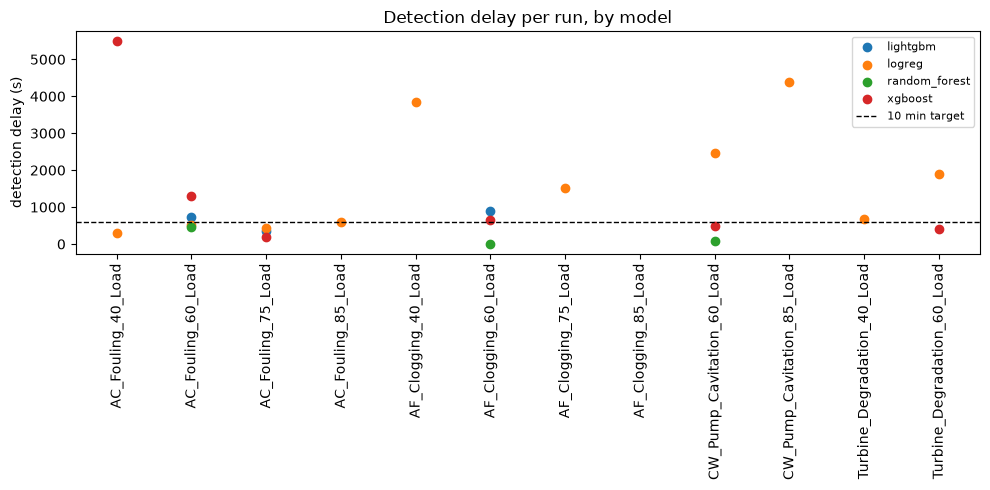

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
for model, group in alarms_results.groupby("model"):
    group = group.sort_values("run")
    ax.scatter(group["run"], group["delay_s"], label=model)
ax.axhline(600, color="black", linestyle="--", linewidth=1, label="10 min target")
ax.set_ylabel("detection delay (s)")
ax.set_title("Detection delay per run, by model")
ax.tick_params(axis="x", rotation=90)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(paths.FIGURES / "04_detection_delay.png", dpi=150)
plt.show()

In [10]:
best_alarms = alarms_results[alarms_results["model"] == best_model]
n_runs = len(best_alarms)
n_detected = best_alarms["delay_s"].notna().sum()
median_delay = best_alarms["delay_s"].median()
print(f"{best_model}: alarm raised on {n_detected} of {n_runs} fault runs")
print(f"median delay among detected runs: {median_delay:.0f} s ({median_delay / 60:.1f} min)")

xgboost: alarm raised on 6 of 13 fault runs
median delay among detected runs: 563 s (9.4 min)


## Scores with and without the first 10 minutes after switch-on

Brief risk "Gradual faults": a fault that ramps in gradually may only
become separable from Normal a few minutes after switch-on, so the raw
pooled score could look worse than the model deserves. Rows in each
fault run's first 10 minutes after switch-on are excluded from the
"excluding first 10 min" row below; everything else about the scoring is
unchanged.

In [11]:
feature_table = experiments.load_feature_table()
switch_on = audit.switch_on_points(feature_table)
switch_on_t = switch_on.set_index("run")["t"]

best_with_t = best_predictions.copy()
best_with_t["t"] = feature_table.loc[best_with_t.index, "t"]
best_with_t["t_switch_on"] = best_with_t["run"].map(switch_on_t)
in_first_10_min = (best_with_t["t"] >= best_with_t["t_switch_on"]) & (
    best_with_t["t"] < best_with_t["t_switch_on"] + 600
)


def _score(label: str, predictions: pd.DataFrame) -> dict[str, object]:
    recall = evaluate.per_class_recall(predictions["y_true"], predictions["y_pred"])
    return {
        "scope": label,
        "n_rows": len(predictions),
        "macro_f1": evaluate.macro_f1(predictions["y_true"], predictions["y_pred"]),
        "accuracy": evaluate.accuracy(predictions["y_true"], predictions["y_pred"]),
        "false_alarm_rate": evaluate.false_alarm_rate(predictions["y_true"], predictions["y_pred"]),
        "worst_recall": recall.min(),
        "worst_recall_class": recall.idxmin(),
    }


first_10_min_scores = pd.DataFrame(
    [
        _score("all rows", best_with_t),
        _score("excluding first 10 min after switch-on", best_with_t[~in_first_10_min]),
    ]
)
evaluate.log_results("04_first_10_min", first_10_min_scores)
first_10_min_scores

,scope,n_rows,macro_f1,accuracy,false_alarm_rate,worst_recall,worst_recall_class
0,all rows,107979,0.717487,0.761268,0.122309,0.194494,TD
1,excluding first 10 min after switch-on,103105,0.724521,0.778924,0.122309,0.198630,TD


## Target table: met or not met

Row-level numbers are the best model's (XGBoost) pooled scores from
`04_models.csv`; the alarm-level number is its median detection delay
among the runs where it ever raised an alarm (`04_alarms.csv`). Targets
from `reports/targets.md` (`docs/adr/0005-targets-kept-after-eda.md`); no
number below is rounded in the model's favour.

In [12]:
best_pooled = pooled[pooled["model"] == best_model].iloc[0]
target_rows = [
    {
        "metric": "Macro F1, held-out loads",
        "value": best_pooled["macro_f1"],
        "target": 0.80,
        "met": bool(best_pooled["macro_f1"] >= 0.80),
    },
    {
        "metric": "Lowest per-class recall",
        "value": best_pooled["worst_recall"],
        "target": 0.70,
        "met": bool(best_pooled["worst_recall"] >= 0.70),
    },
    {
        "metric": "False alarm rate",
        "value": best_pooled["false_alarm_rate"],
        "target": 0.05,
        "met": bool(best_pooled["false_alarm_rate"] <= 0.05),
    },
    {
        "metric": "Detection delay (median of detected runs)",
        "value": median_delay,
        "target": 600.0,
        "met": bool(pd.notna(median_delay) and median_delay <= 600 and n_detected == n_runs),
    },
]
target_table = pd.DataFrame(target_rows)
evaluate.log_results("04_targets", target_table)
target_table

,metric,value,target,met
0,"Macro F1, held-out loads",0.717487,0.80,False
1,Lowest per-class recall,0.194494,0.70,False
2,False alarm rate,0.122309,0.05,False
3,Detection delay (median of detected runs),563.000000,600.00,False


## Best model recorded: `04_best_model.csv`

R13: pick by pooled macro F1, tie-broken by lowest per-class recall then
false alarm rate. XGBoost leads on macro F1 alone (0.717 vs 0.667 for the
next model), so no tie-break is needed. Its per-fold tuned params and
scores are the record of the decision
(`docs/adr/0007-best-model-for-detection.md`).

In [13]:
best_scores = models_results[models_results["model"] == best_model][
    ["fold", "macro_f1", "accuracy", "false_alarm_rate", "worst_recall", "worst_recall_class"]
].copy()
best_params = tuned_params[tuned_params["model"] == best_model].drop(columns=["model"]).copy()
best_params = best_params.dropna(axis="columns", how="all")
best_params["fold"] = best_params["fold"].astype(str)
best_model_table = best_scores.merge(best_params, on="fold", how="left")
best_model_table.insert(0, "model", best_model)
evaluate.log_results("04_best_model", best_model_table)
best_model_table

,model,fold,macro_f1,accuracy,false_alarm_rate,worst_recall,worst_recall_class,learning_rate,n_estimators,reg_lambda,max_depth,subsample,colsample_bytree
0,xgboost,pooled,0.717487,0.761268,0.122309,0.194494,TD,NaN,NaN,NaN,NaN,NaN,NaN
1,xgboost,40,0.546666,0.709470,0.098993,0.000000,TD,0.178853,63.0,0.120302,2.0,0.831261,0.655856
2,xgboost,60,0.860488,0.878279,0.076194,0.571322,TD,0.178853,63.0,0.120302,2.0,0.831261,0.655856
3,xgboost,75,0.700630,0.675484,0.252734,0.336338,AF,0.139837,80.0,7.579480,2.0,0.854036,0.510292
4,xgboost,85,0.608770,0.730807,0.096783,0.000000,AF,0.003357,59.0,0.125610,7.0,0.591702,0.652121


## What this means for the next notebook

**Findings:**

1. XGBoost is the best model on pooled macro F1 (0.717, accuracy 0.761),
   ahead of LightGBM (0.667), random forest (0.648) and logreg (0.542),
   but none reach the 0.80 target and XGBoost's false alarm rate (12.2%)
   is more than double the 5% target.
2. XGBoost's alarm only fires on 6 of the 13 fault runs at all; the
   median delay among those (563 s / 9.4 min) looks close to the
   10-minute target, but half the runs never trigger a sustained alarm,
   so the detection-delay target is not met once the undetected runs are
   counted honestly.
3. Scores with and without each run's first 10 minutes after switch-on
   are close, so gradual fault onset is not masking a materially better
   model; the shortfall against the targets is real, not a scoring
   artefact.

Numbers above are read from the executed run, not tuned to hit a target.
T-007 records the best-model decision and what it means for the targets
in `docs/adr/`.